# Convert an image file (MELLON TI Map) into numpy file and store

"The thermal inertia of Mars is a physical property that controls the diurnal and seasonal cycles in surface temperature. It is defined as a function of the thermal conductivity, heat capacity, and density, all of which depend primarily on the physical structure of the surface layer. As such, thermal inertia provides information about the nature of the surface of Mars and the types of materials from which it is composed. Interpreting thermal inertia can be complicated by the variety of structures and material properties that result in the same thermal inertia value. In general, variations in the thermal conductivity have the greatest influence on the thermal inertia. Factors such as soil grain size, cementing or induration, rock abundance, the presence of bedrock, and surface heterogeneity all play an important role." - https://www.cambridge.org/core/books/martian-surface/thermal-inertia-of-the-surface-of-mars/683F86021F4BB3790DD78C4C2513DF45 

EMM gives us Surface Temperature over large areas that allows us to study the **thermal inertia** variations across MARS over different Solar Longitudes. Before we develop this data product, we need to compare the thermal inertia obtained via EMM with multiple other missions. We use the **Mellon Maps** created using TES Bolometric Data, and THEMIS thermal inertia maps.

In this program we read the Mellon Maps using the **`pdr` library** developed by NASA. The size of the file is 3600 X 7200. We average 1x1 degree Lat Lon and store as a numpy file for other programs in the pipeline to process and use.

**Data Format**: Image (Read using the PDR library from NASA)

https://se.psi.edu/inertia/2007/ 

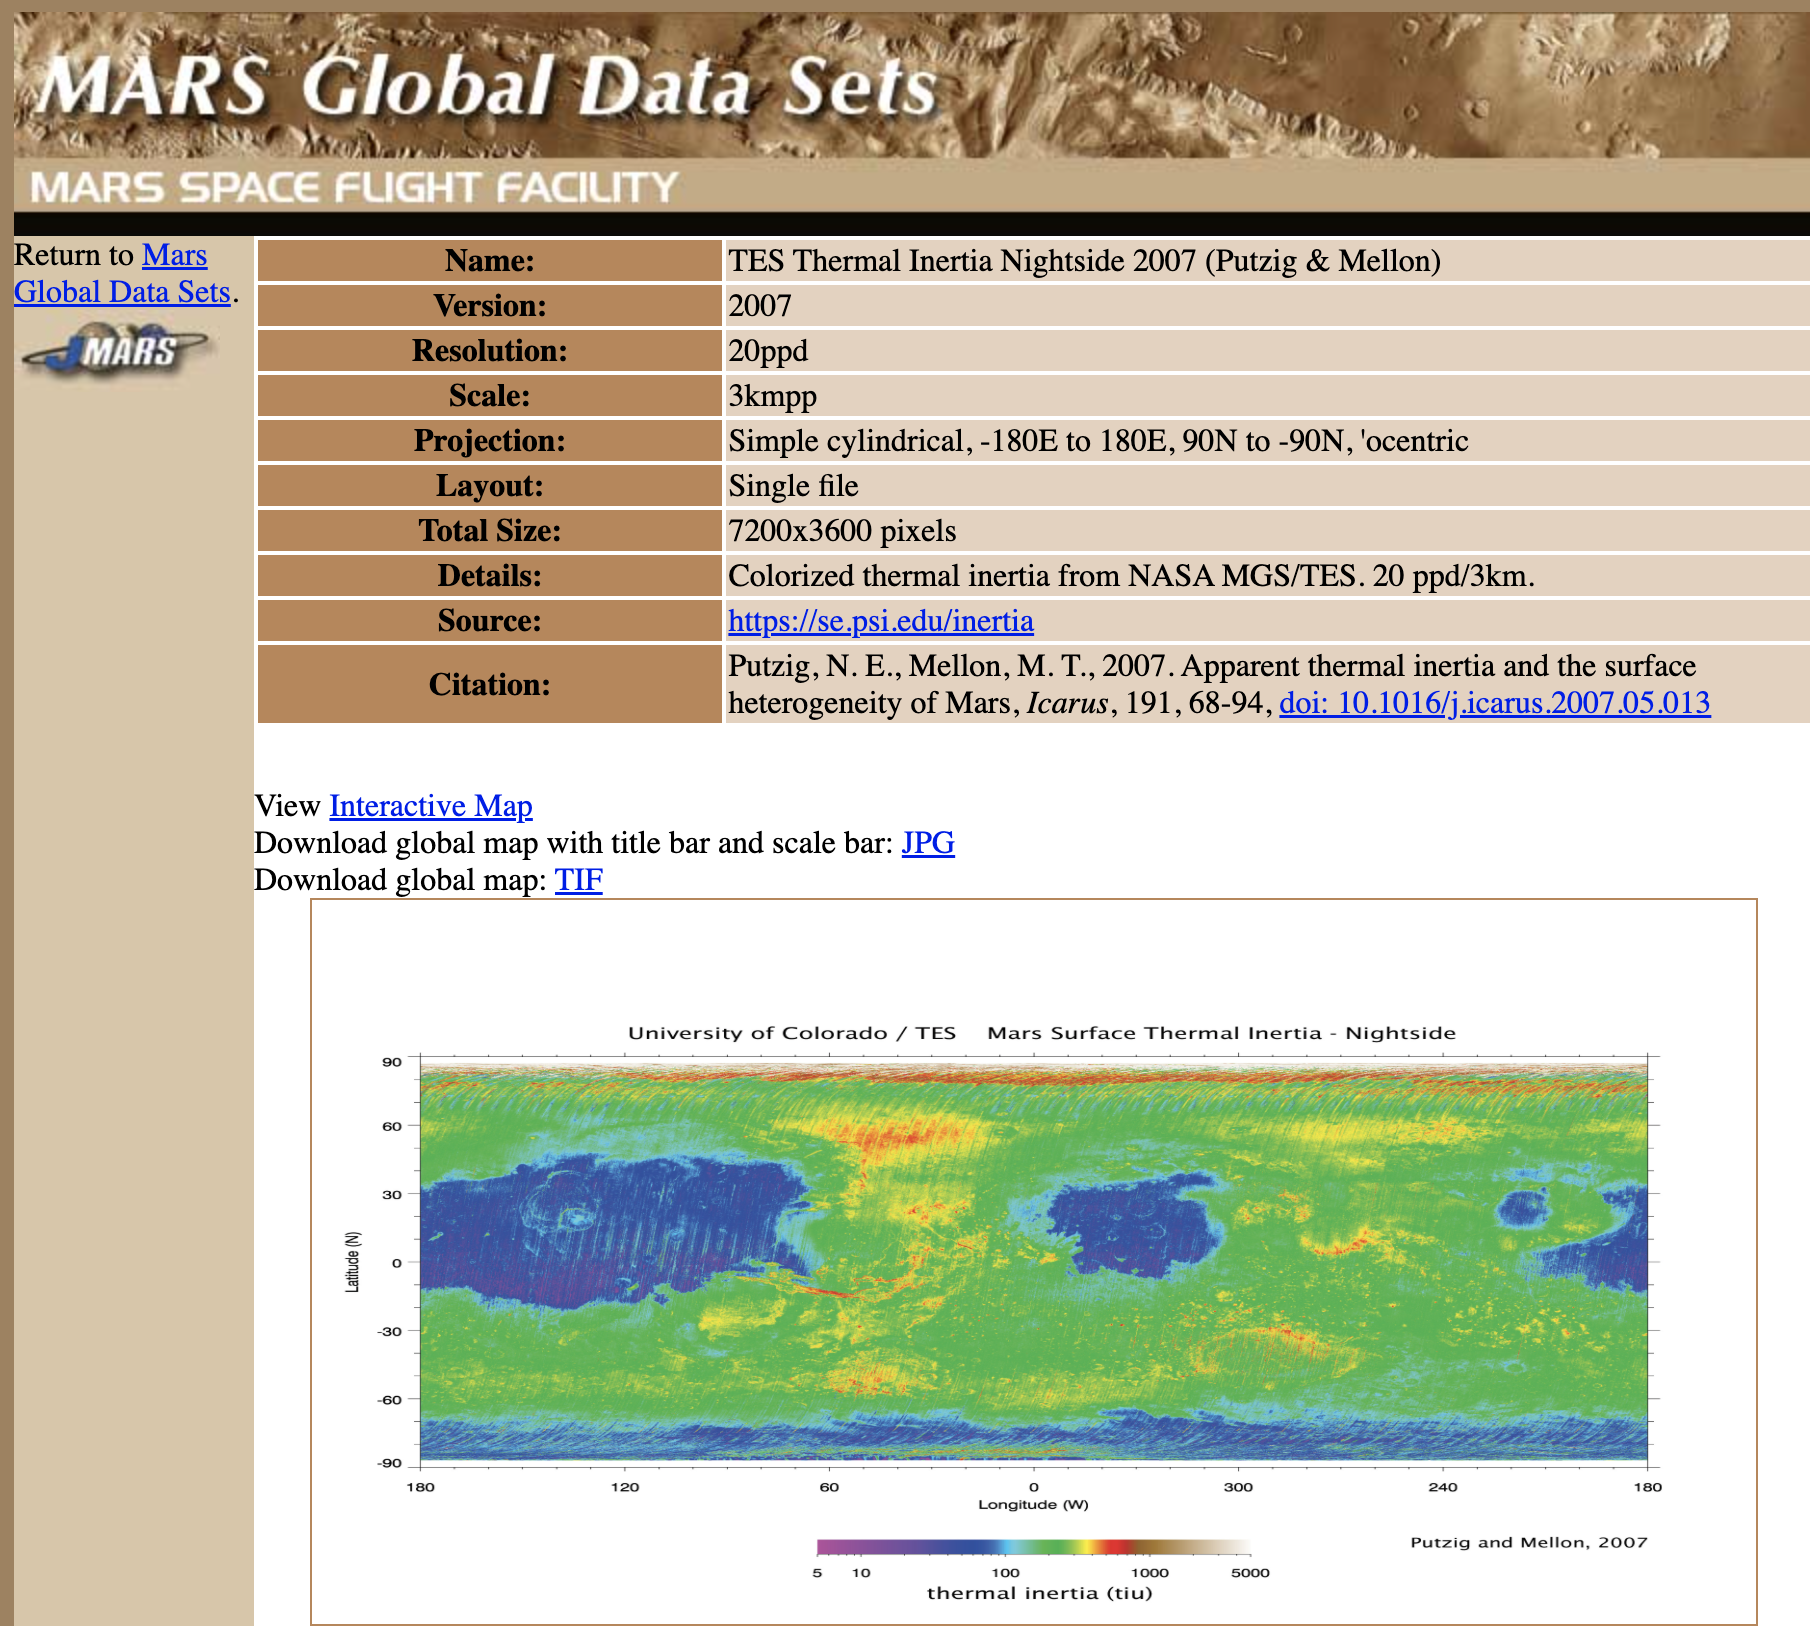

## DATA 

Input: Image file 

In [7]:
#from PIL import Image
import matplotlib.pyplot as plt
import pdr
import os
import requests
import numpy as np
import pandas as pd

In [8]:
filename = '/scratch/pk97/krc/mgst_9001/data/global_ti_night_2007.img'
lroc_data = pdr.read(filename)  # That's the magic function call!
print(f'The keys are {lroc_data.keys()}')

The keys are ['LABEL', 'IMAGE', 'DATA_SET_MAP_PROJECTION']


In [9]:
lroc_data.IMAGE

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype='>i2')

In [10]:
for key in lroc_data.keys():
    print(f'{key}:')
    print(lroc_data[key])

LABEL:
PDS_VERSION_ID                 = PDS3
RECORD_TYPE                    = FIXED_LENGTH
FILE_RECORDS                   = 3600
RECORD_BYTES                   = 14400
^IMAGE                         = "GLOBAL_TI_NIGHT_2007.IMG"

DATA_SET_ID                    = "MGS-M-TES-5-TIMAP-V1.0"
PRODUCT_ID                     = "GLOBAL_TI_NIGHT_2007"
MISSION_NAME                   = "MARS GLOBAL SURVEYOR"
INSTRUMENT_HOST_NAME           = "MARS GLOBAL SURVEYOR"
INSTRUMENT_NAME                = "THERMAL EMISSION SPECTROMETER"
TARGET_NAME                    = "MARS"
START_TIME                     = "N/A"
STOP_TIME                      = "N/A"
SPACECRAFT_CLOCK_START_COUNT   = "N/A"
SPACECRAFT_CLOCK_STOP_COUNT    = "N/A"
PRODUCT_CREATION_TIME          = 2007-01-30
PRODUCER_FULL_NAME             = "NATHANIEL PUTZIG"
PRODUCER_INSTITUTION_NAME      = "SOUTHWEST RESEARCH INSTITUTE"

OBJECT                         = IMAGE
  LINES                        = 3600
  LINE_SAMPLES                 = 7200
  SAMPLE

/home/pk97/.conda/envs/marslab2/lib/python3.12/site-packages/pdr/pdr.py:444: UserWarning: DATA_SET_MAP_PROJECTION file [PosixPath('/scratch/pk97/krc/mgst_9001/data/DSMAP.CAT')] not found in path.
  warnings.warn(


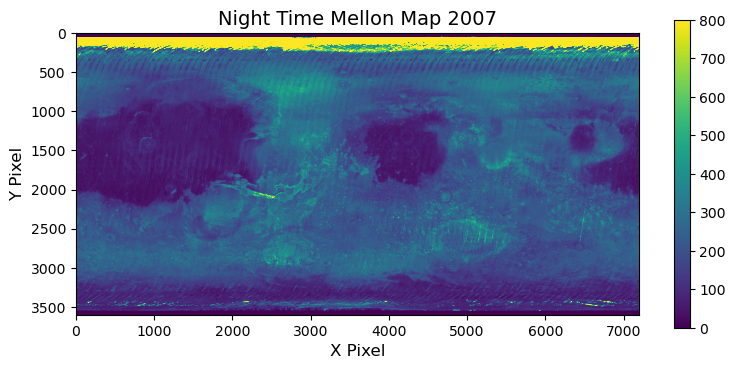

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))  

im = ax.imshow(lroc_data.IMAGE, vmin=0, vmax=800)

# Add a more informative title
ax.set_title("Night Time Mellon Map 2007", fontsize=14)
ax.set_xlabel("X Pixel", fontsize=12)
ax.set_ylabel("Y Pixel", fontsize=12)

# Add a colorbar with a label
cbar = fig.colorbar(im, ax=ax, shrink=0.4, location='right')  # Specify location
#cbar.set_label("Intensity Value", fontsize=12)

# Improve tick label appearance
ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()  
plt.show()

In [16]:
lroc_data.IMAGE.shape

(3600, 7200)

In [22]:
new_image_array = lroc_data.IMAGE

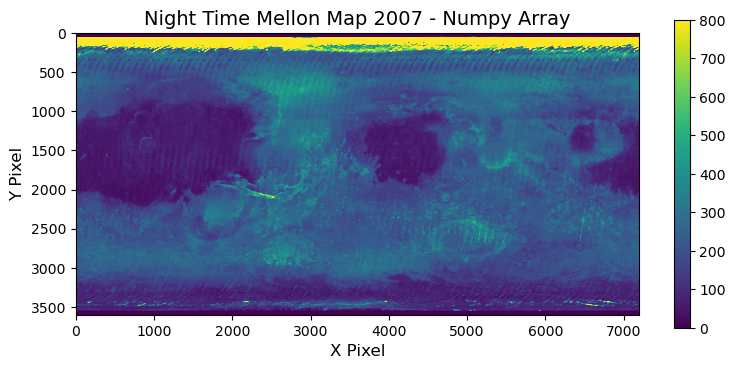

In [23]:
fig, ax = plt.subplots(figsize=(8, 8))  

im = ax.imshow(new_image_array, vmin=0, vmax=800)

# Add a more informative title
ax.set_title("Night Time Mellon Map 2007 - Numpy Array", fontsize=14)
ax.set_xlabel("X Pixel", fontsize=12)
ax.set_ylabel("Y Pixel", fontsize=12)

# Add a colorbar with a label
cbar = fig.colorbar(im, ax=ax, shrink=0.4, location='right')  # Specify location
#cbar.set_label("Intensity Value", fontsize=12)

# Improve tick label appearance
ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()  
plt.show()

In [24]:
new_image_array.shape

(3600, 7200)

In [25]:
# rolling window 20X20 (3600/180 & 7200/360)
# Create an average map

# Initialize an array 
x_lon = 360
y_lat = 180
new_array = np.zeros([y_lat, x_lon], dtype=float)

step_size = 20

for i in range(0, y_lat): # rows
    for j in range(0, x_lon): # columns
        mean_TI = 0
        col_start = 0
        col_end = 19 # start with first 5
        row_start = i * step_size
        row_end = 19 # start with first 5 
        
        #Move our averaging window of 20X20 across the columns with rows remaining the same
        
        new_array[i,j] = new_image_array[(row_start):(row_start+row_end), 
                         (col_start + j*step_size):(col_end + j*step_size) ].mean()
        
        #df_degrees.at[i,j] = df_mean.mean().mean()




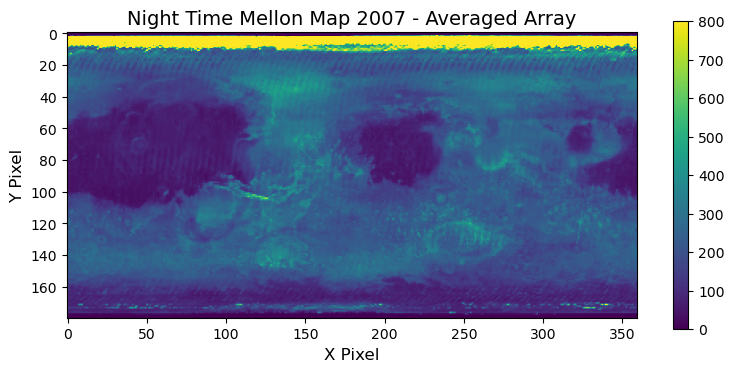

In [26]:
#plt.imshow(new_array[0:180,0:360], vmin=0, vmax=800)
#cbar = plt.colorbar(shrink=0.35) 
#plt.show()


fig, ax = plt.subplots(figsize=(8, 8))  

im = ax.imshow(new_array[0:180,0:360], vmin=0, vmax=800)

# Add a more informative title
ax.set_title("Night Time Mellon Map 2007 - Averaged Array", fontsize=14)
ax.set_xlabel("X Pixel", fontsize=12)
ax.set_ylabel("Y Pixel", fontsize=12)

# Add a colorbar with a label
cbar = fig.colorbar(im, ax=ax, shrink=0.4, location='right')  # Specify location
#cbar.set_label("Intensity Value", fontsize=12)

# Improve tick label appearance
ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()  
plt.show()

In [22]:
# write and store numpy file 

path = '/scratch/pk97/krc/krc_codes/Data/'
filename = 'Mellon_Night_Time_TI_map_180_360.npy'
np.save(path+filename, new_array)